In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/content/Titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Q1. Create a countplot to show the number of passengers by gender.**

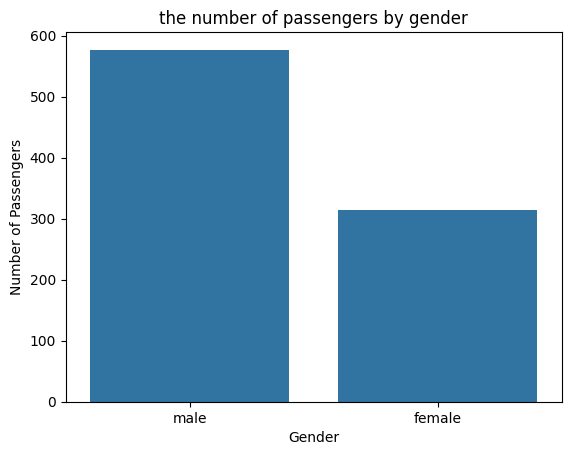

In [ ]:
sns.countplot(x='Sex',data=df)

plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.title('the number of passengers by gender')

plt.show()

Sex
male      577
female    314
Name: count, dtype: int64


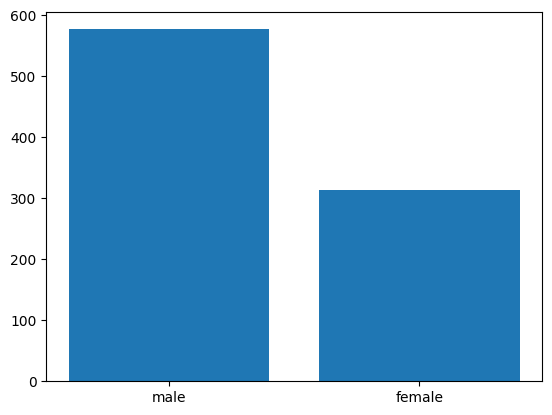

In [ ]:
gender_counts=df['Sex'].value_counts()
print(gender_counts)

plt.bar(gender_counts.index,gender_counts.values)
plt.show()

**Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.**

In [ ]:
no_of_pass=df.groupby('Pclass')['Name'].count()
print(no_of_pass)

Pclass
1    216
2    184
3    491
Name: Name, dtype: int64


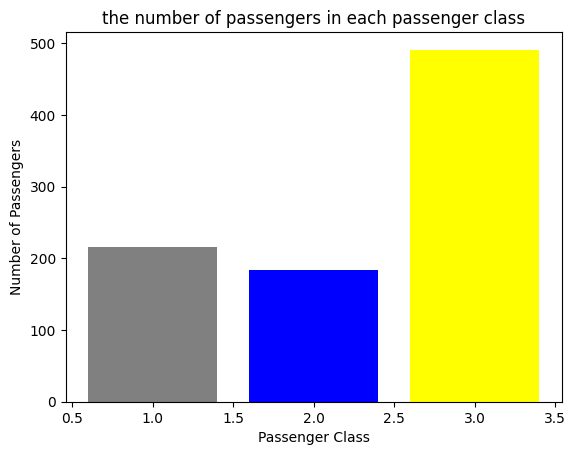

In [ ]:

plt.bar(no_of_pass.index,no_of_pass.values,color=['grey','blue','yellow'])
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.title('the number of passengers in each passenger class')

plt.show()

**Q3. Create a histogram to show the distribution of passenger age.**

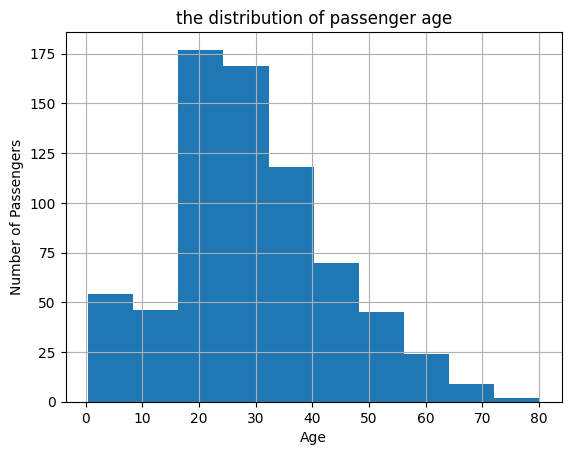

In [ ]:
df.Age.hist()
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('the distribution of passenger age')

plt.show()

**Q4. Create a boxplot to detect outliers in the fare column.**

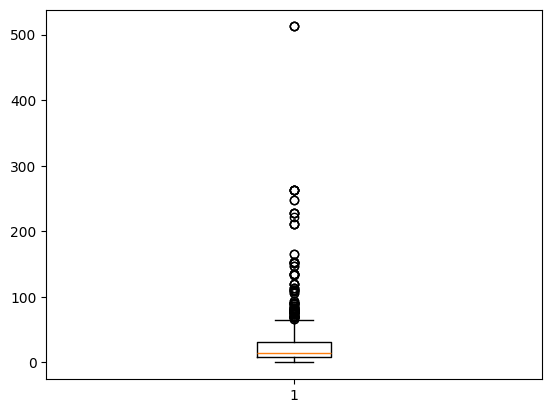

In [ ]:
plt.boxplot(df['Fare'])
plt.show()

In [7]:
Q1=df['Fare'].quantile(0.25)
Q3=df['Fare'].quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outliers=df[(df['Fare']<lower_bound) | (df['Fare']>upper_bound)]
print(outliers)

     PassengerId  Survived  Pclass  \
1              2         1       1   
27            28         0       1   
31            32         1       1   
34            35         0       1   
52            53         1       1   
..           ...       ...     ...   
846          847         0       3   
849          850         1       1   
856          857         1       1   
863          864         0       3   
879          880         1       1   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
27                      Fortune, Mr. Charles Alexander    male  19.0      3   
31      Spencer, Mrs. William Augustus (Marie Eugenie)  female   NaN      1   
34                             Meyer, Mr. Edgar Joseph    male  28.0      1   
52            Harper, Mrs. Henry Sleeper (Myna Haxtun)  female  49.0      1   
..                                                 ...     ...   ... 

**Q5. Create a scatterplot to**

**a. show the relationship between age and fare.**

**b. analyze the relationship between family size (SibSp + Parch) and fare.**

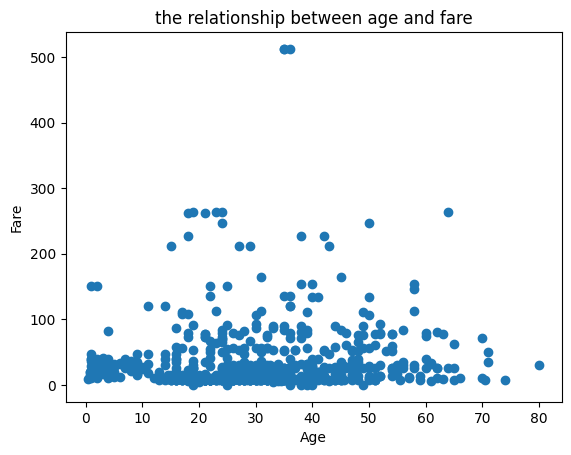

In [ ]:
## a. show the relationship between age and fare.

plt.scatter(df['Age'],df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('the relationship between age and fare')

plt.show()

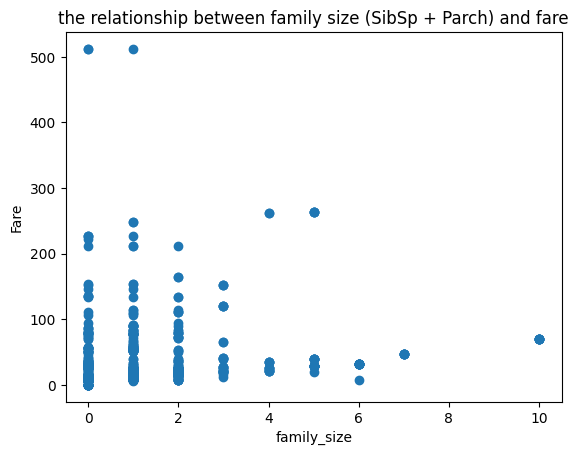

In [ ]:
## b. analyze the relationship between family size (SibSp + Parch) and fare.

df['family_size'] = df['SibSp'] + df['Parch']

plt.scatter(df['family_size'],df['Fare'])
plt.xlabel('family_size')
plt.ylabel('Fare')
plt.title('the relationship between family size (SibSp + Parch) and fare')

plt.show()


**Q6. Create a countplot to show survival count by gender.**

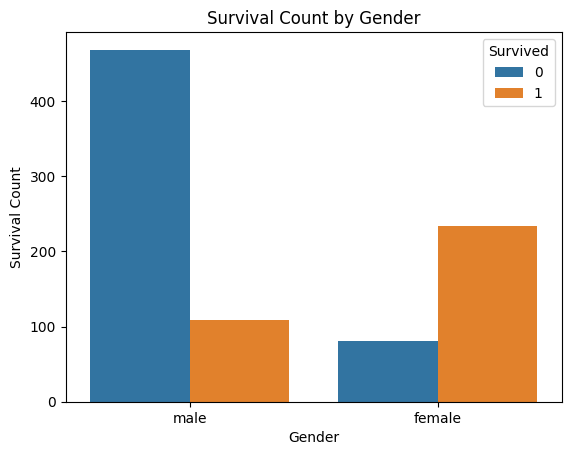

In [ ]:
sns.countplot(data=df, x='Sex', hue='Survived')

plt.xlabel('Gender')
plt.ylabel('Survival Count')
plt.title('Survival Count by Gender')

plt.show()

**Q7. Create a bar chart to show survival by passenger class.**

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64


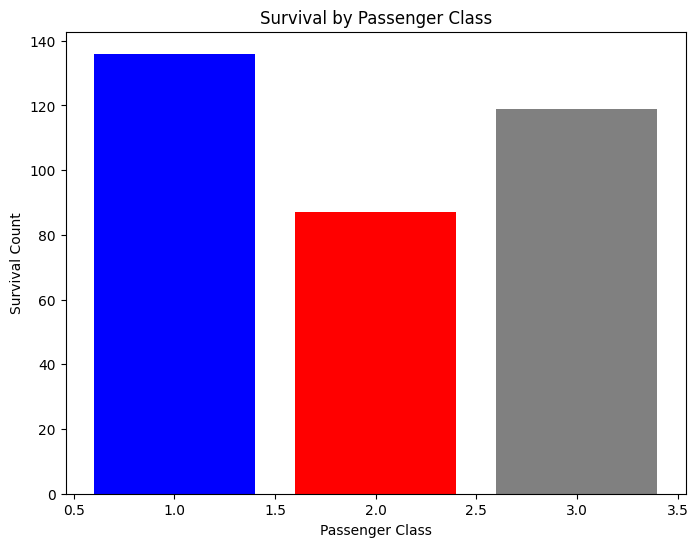

In [ ]:
pass_survival=df.groupby('Pclass')['Survived'].sum()
print(pass_survival)

plt.figure(figsize=(8,6))
plt.bar(pass_survival.index,pass_survival.values,color=['blue','red','grey'])
plt.xlabel('Passenger Class')
plt.ylabel('Survival Count')
plt.title('Survival by Passenger Class')

plt.show()


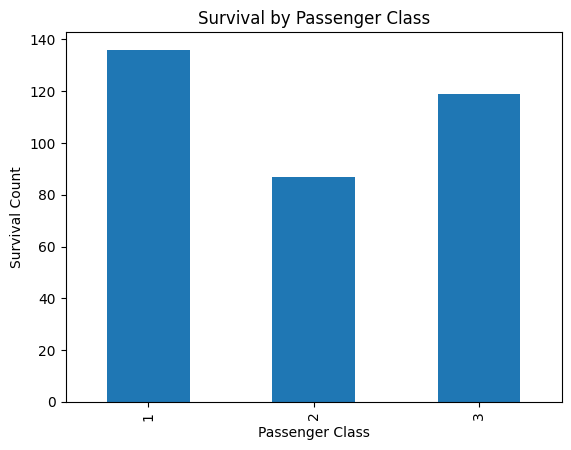

In [ ]:
df.groupby('Pclass')['Survived'].sum().plot(kind='bar')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Count')
plt.title('Survival by Passenger Class')

plt.show()




**Q8. Create a heatmap to show correlation between numerical variables.**

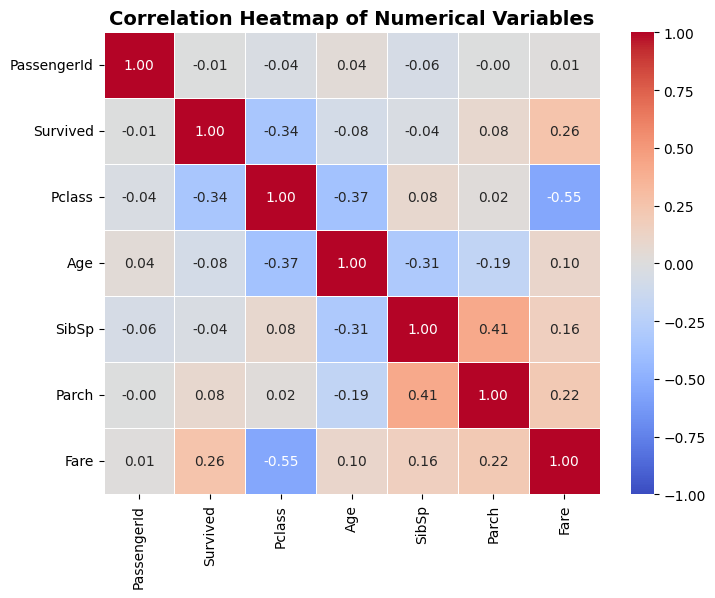

In [ ]:
numerical_df = df.select_dtypes(include=['number'])

corr_matrix = numerical_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Numerical Variables', fontsize=14, fontweight='bold')

plt.show()

**Q9. Identify which passenger class paid the highest fare on average.**

In [ ]:
highestfare=df.groupby('Pclass')['Fare'].mean().sort_values(ascending=False).head(1).reset_index(name='Average Fare')
highestfare.style.set_caption("<b>Average Ticket Fare by Passenger Class")

,Pclass,Average Fare
0,1,84.154687


**Q10. Write at least 5 insights from the dataset based on your visualizations.**

**A-**

- Here male passengers(577) are higher than female passangers(314)

- Here number of passangers in 1st class is 216, in 2nd class is 184 and in 3rd class is 491.It means 3rd class has highest passanger and 2nd class has lowest passanger.

- Here number of passangers are high in age 20 and number of paasangers are low in age 80.

- Here number of passangers survived highest in 1st class(136), then 3rd class(119) and number of passangers survived lowest in 2nd class(87).

- Here male passangers survived highest than female passangers.
